# 06 — Feed-forward network

**Purpose**: Ten-fold cross-validation with folds assigned over `Strata`, so a matched pair neverstraddles the train/test boundary. 

The fold assignment is the shared one in`osteo_pipeline.folds`, so the test blocks match notebook 05 fold for fold.

Machinery lives in `src/osteo_pipeline/` (shared) and `src/osteo_pipeline/ann/`(this stage). 

This notebook picks the architecture, runs the loop, reads the result.

# 1. Setup

In [1]:
#warming up TF
import numpy as np
import tensorflow as tf

X_toy = np.random.rand(200, 5).astype('float32')
y_toy = np.random.randint(0, 2, 200).astype('float32')

toy = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(5,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
toy.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print('about to fit...')
toy.fit(X_toy, y_toy, epochs=2, batch_size=32, verbose=2)
print('fit finished OK')

about to fit...
Epoch 1/2
7/7 - 0s - 29ms/step - accuracy: 0.4800 - loss: 0.6918
Epoch 2/2
7/7 - 0s - 1ms/step - accuracy: 0.4800 - loss: 0.6914
fit finished OK


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from osteo_pipeline import (
    SEED,
    OHE_FILE,
    check_frame,
    load_column_groups,
)

from osteo_pipeline import split_ever_columns, DATA_DIR
from osteo_pipeline.ANN import (
    ANNSpec,
    make_ann,
    summarize_ann,
    TrainConfig,
    TRAIN_MODEL_ANN,
)

np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG_FILE = PROJECT_ROOT / "notebooks" / "config_ml.yaml"

# 2. Data

In [3]:
KEYS, GROUPS_RAW, GROUPS = load_column_groups(CONFIG_FILE)

data_OHE = pd.read_csv(OHE_FILE, low_memory=False)
MODEL_COLS = [c for c in data_OHE.columns if c not in KEYS]

check_frame(data_OHE, MODEL_COLS)

frame OK — 61,026 rows, 30,513 strata, 49 features, label counts {0: 30513, 1: 30513}


# 3. Architecture

Two hidden layers, dropout after the first, L2 on the second. 

`ANNSpec` is the singleplace these numbers are written down; 

`make_ann` turns it into a builder the loopcalls once per fold, so every fold starts from fresh weights.

In [4]:
spec = ANNSpec(h1=120, h2=100, dropout=0.5, learning_rate=0.001)
builder = make_ann(spec)

_ = summarize_ann(spec, n_features=len(MODEL_COLS))

Model: "osteo_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 120)            │         6,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_hidden (Dropout)        │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 100)            │        12,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,201 (71.10 KB)

 Trainable params: 18,201 (71.10 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Cross-validation run

In [5]:
EVER_COLS, NO_EVER_COLS = split_ever_columns(MODEL_COLS, GROUPS_RAW)
print(len(MODEL_COLS), "->", len(NO_EVER_COLS), "features;", "dropped:", EVER_COLS)
assert len(NO_EVER_COLS) == 43

49 -> 43 features; dropped: ['Calcium_Avg_Ever_decile', 'Sodium_Avg_Ever_decile', 'Sodium_Worst_Ever_decile', 'Calcium_Avg_Ever_measured', 'Sodium_Avg_Ever_measured', 'Sodium_Worst_Ever_measured']


fold  1  train strata 23,342  val strata  4,119  test strata  3,052  train acc 0.7080


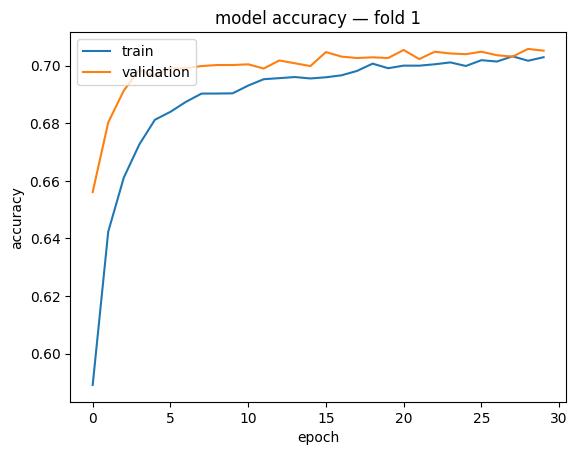

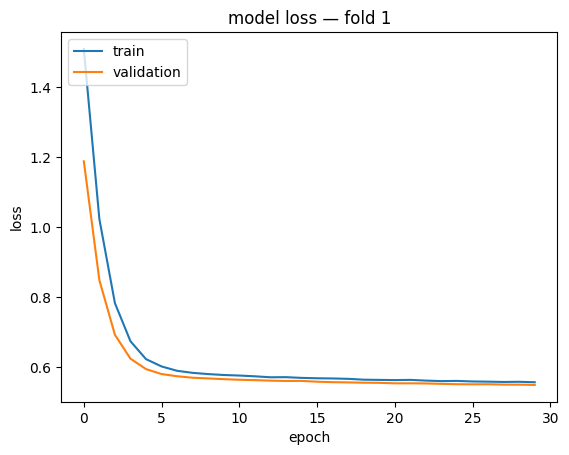

fold  2  train strata 23,342  val strata  4,119  test strata  3,052  train acc 0.7102


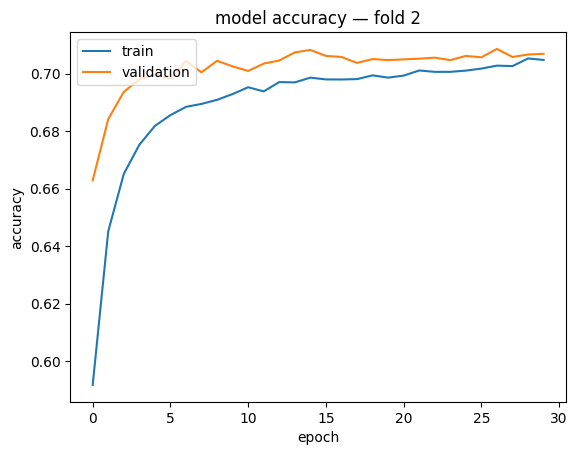

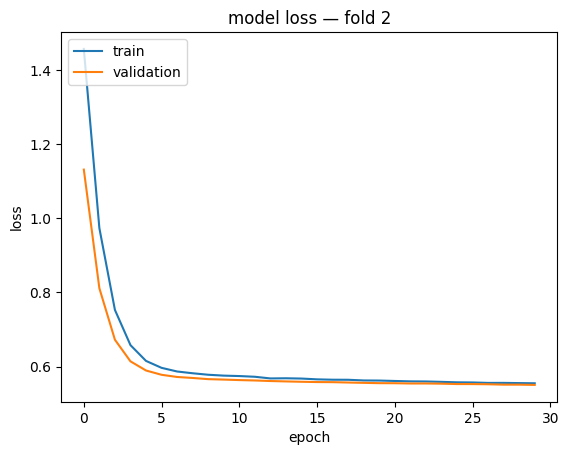

fold  3  train strata 23,342  val strata  4,119  test strata  3,052  train acc 0.7111


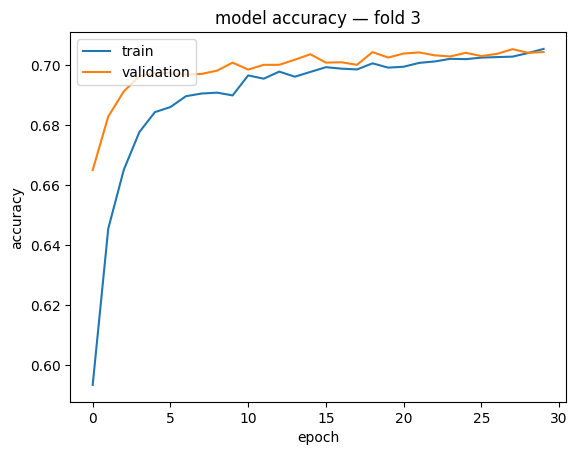

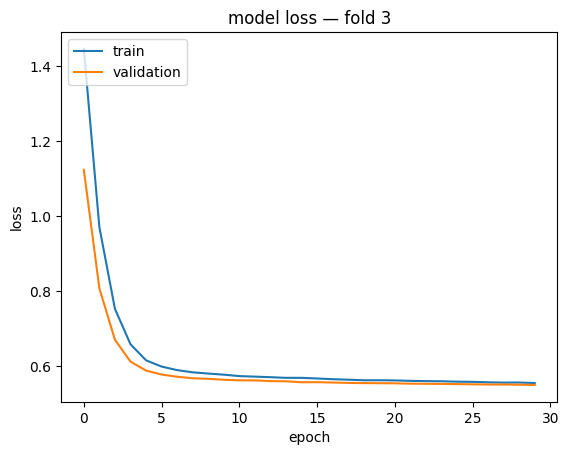

fold  4  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7090


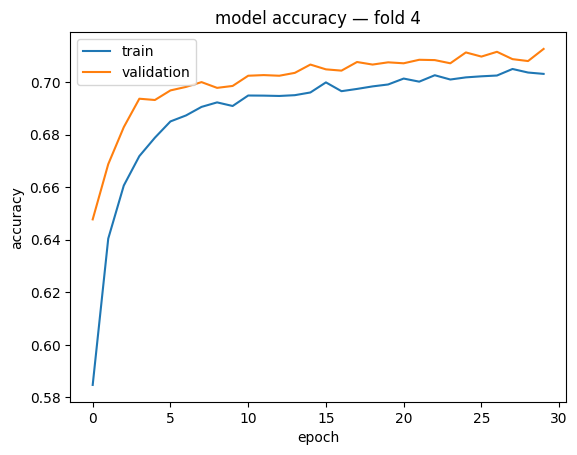

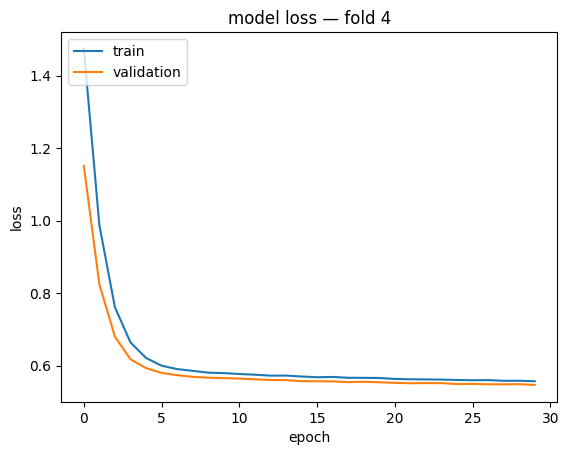

fold  5  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7108


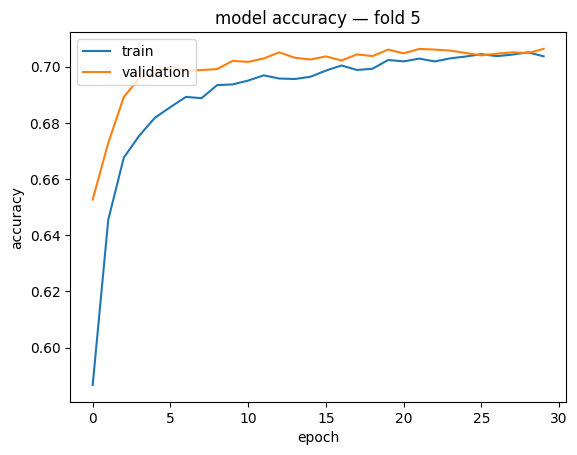

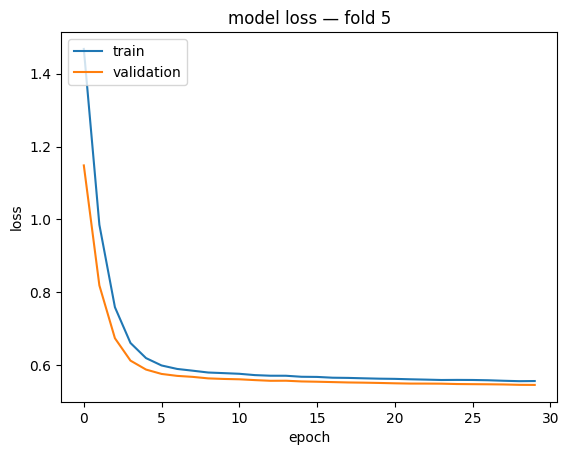

fold  6  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7102


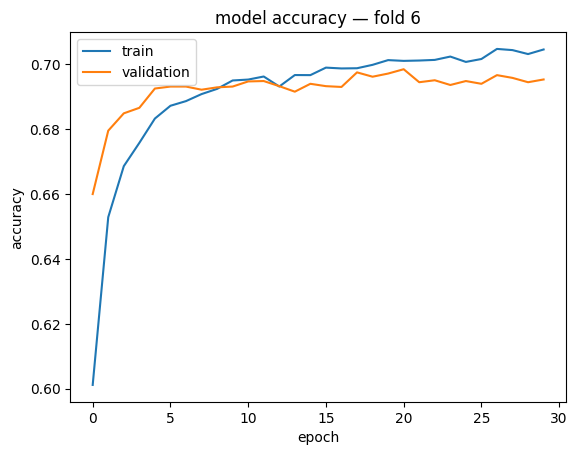

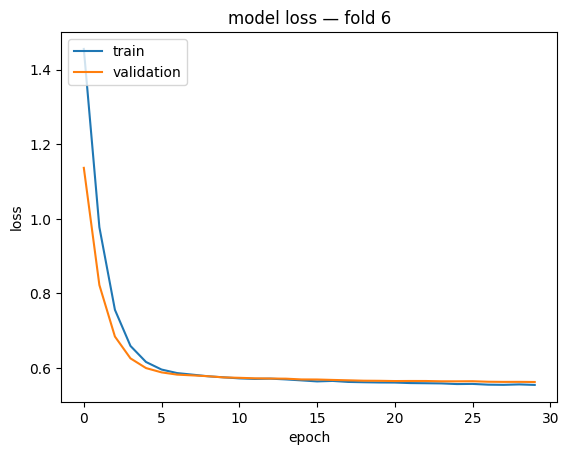

fold  7  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7101


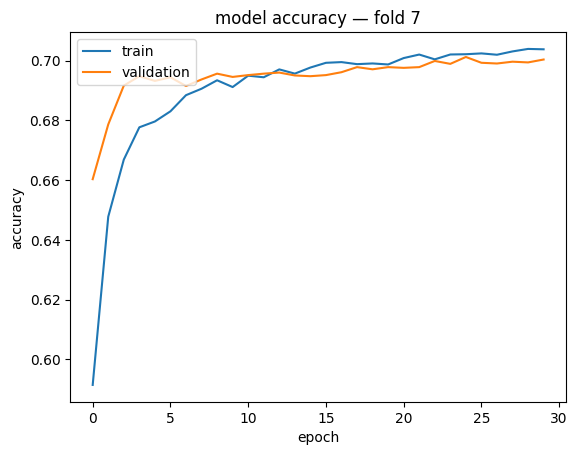

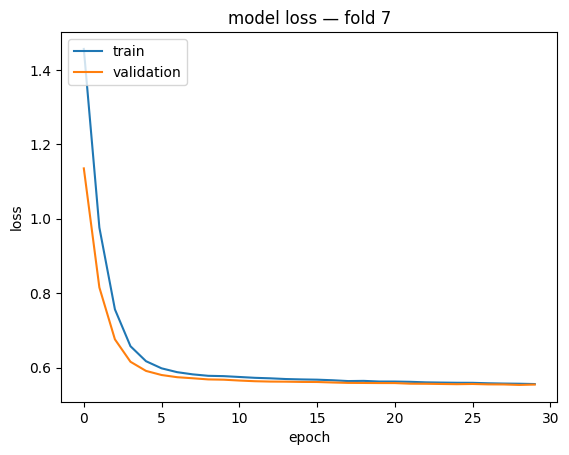

fold  8  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7081


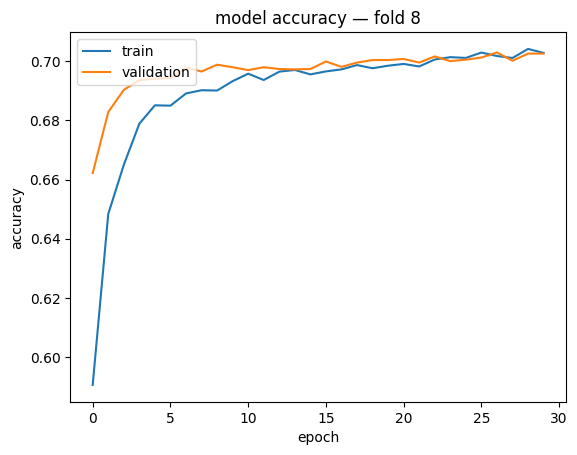

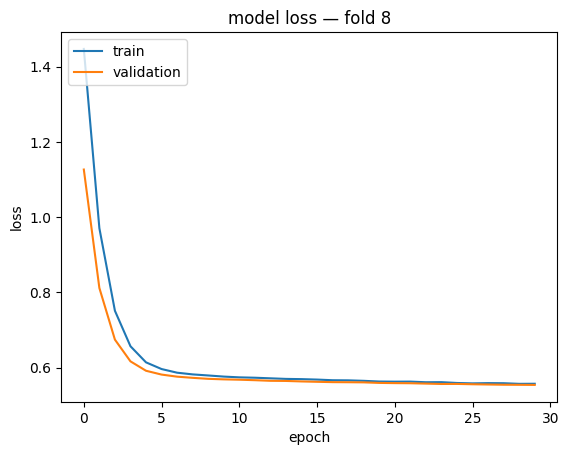

fold  9  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7088


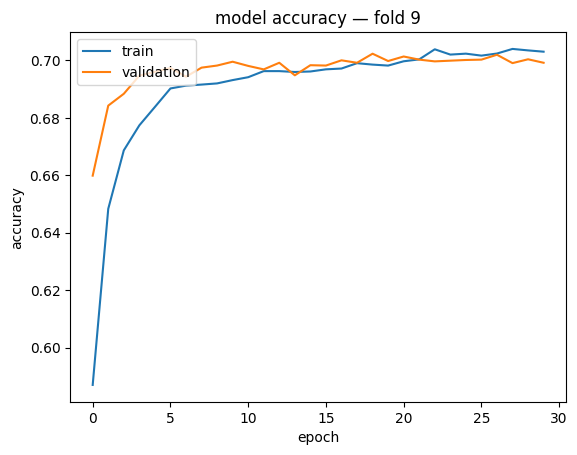

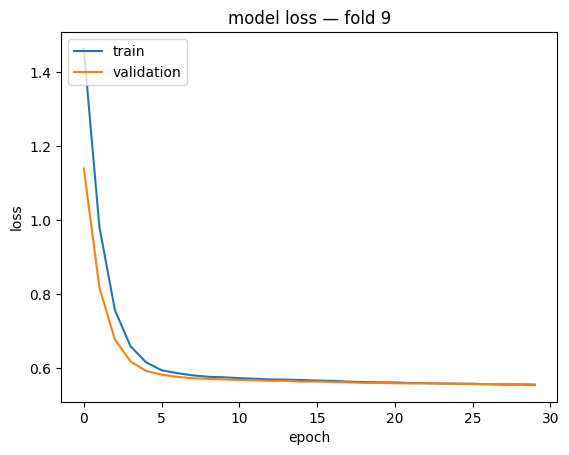

fold 10  train strata 23,343  val strata  4,119  test strata  3,051  train acc 0.7125


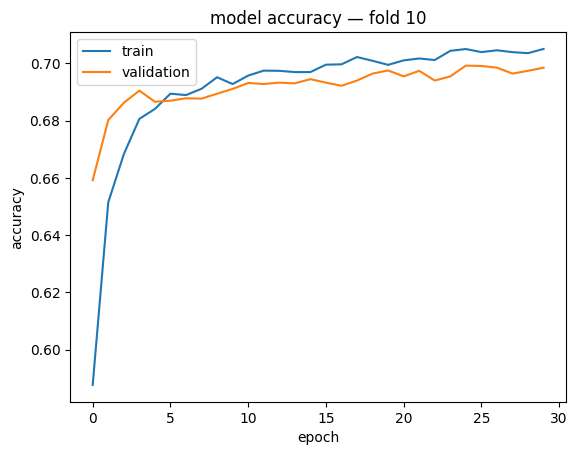

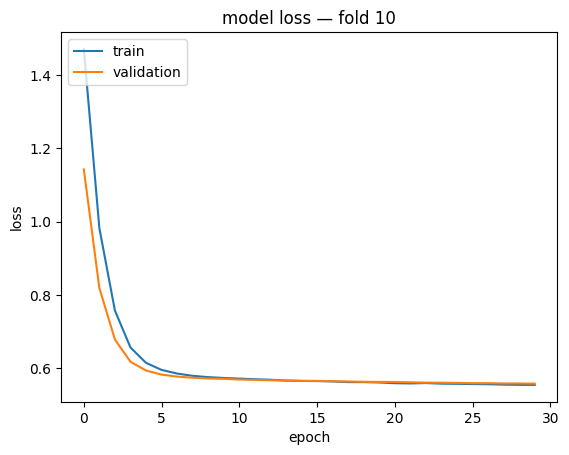


mean train accuracy:  0.7099
out-of-fold accuracy: 0.7044
AUC of whole model:   0.7767 

classification_report of whole model:
               precision    recall  f1-score   support

           0      0.667     0.816     0.734     30513
           1      0.763     0.593     0.667     30513

    accuracy                          0.704     61026
   macro avg      0.715     0.704     0.701     61026
weighted avg      0.715     0.704     0.701     61026
 

confusion_matrix of whole model:
 [[24898  5615]
 [12425 18088]] 



In [6]:
config = TrainConfig(n_splits=10, epochs=30, batch_size=1024, verbose=0)
run = TRAIN_MODEL_ANN(data_OHE, builder, NO_EVER_COLS, config=config, plot_folds=True)

# 5. Results`run.predictions` is the input frame plus `probability` (the held-out probability fromthe fold that scored that row) and `all_preds` (that probability thresholded).

In [7]:
print("AUC:", round(run.auc, 4))
print("out-of-fold accuracy:", round(run.oof_accuracy, 4))
print("train/test accuracy gap:",
      round(np.mean(run.fold_train_accuracy) - run.oof_accuracy, 4))

run.predictions[["Strata", "osteo_label", "probability", "all_preds"]].head()

AUC: 0.7767
out-of-fold accuracy: 0.7044
train/test accuracy gap: 0.0055


,Strata,osteo_label,probability,all_preds
0,9576,0,0.378989,0
1,13833,0,0.318817,0
2,28858,0,0.333898,0
3,16496,0,0.418571,0
4,1,1,0.682069,1


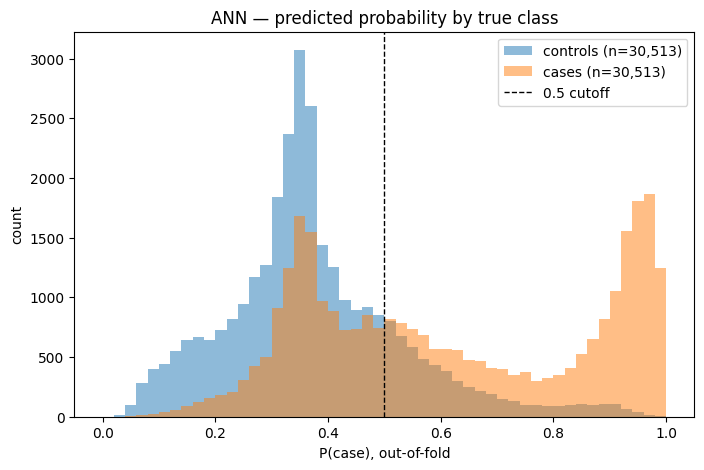

In [8]:
import matplotlib.pyplot as plt

preds = run.predictions
PROB_COL = "probability"
LABEL_COL = "osteo_label"

controls = preds.loc[preds[LABEL_COL] == 0, PROB_COL]
cases = preds.loc[preds[LABEL_COL] == 1, PROB_COL]

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(0, 1, 51)
ax.hist(controls, bins=bins, alpha=0.5, label=f"controls (n={len(controls):,})")
ax.hist(cases, bins=bins, alpha=0.5, label=f"cases (n={len(cases):,})")

ax.axvline(0.5, color="k", linestyle="--", linewidth=1, label="0.5 cutoff")

ax.set_xlabel("P(case), out-of-fold")
ax.set_ylabel("count")
ax.set_title("ANN — predicted probability by true class")
ax.legend()

plt.show()

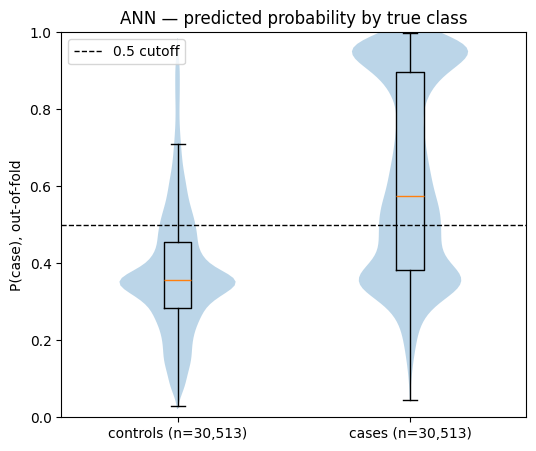

In [9]:
import matplotlib.pyplot as plt

preds = run.predictions
groups = [preds.loc[preds["osteo_label"] == 0, "probability"],
          preds.loc[preds["osteo_label"] == 1, "probability"]]

fig, ax = plt.subplots(figsize=(6, 5))

ax.violinplot(groups, showmedians=False, showextrema=False)
ax.boxplot(groups, widths=0.12, showfliers=False)

ax.axhline(0.5, color="k", linestyle="--", linewidth=1, label="0.5 cutoff")

ax.set_xticks([1, 2])
ax.set_xticklabels([f"controls (n={len(groups[0]):,})",
                    f"cases (n={len(groups[1]):,})"])
ax.set_ylabel("P(case), out-of-fold")
ax.set_ylim(0, 1)
ax.set_title("ANN — predicted probability by true class")
ax.legend(loc="upper left")

plt.show()

In [10]:
summary = (
    preds.groupby(LABEL_COL)[PROB_COL]
    .describe(percentiles=[0.25, 0.5, 0.75])[["count", "25%", "50%", "75%"]]
    .rename(index={0: "controls", 1: "cases"})
)
summary["frac_above_0.5"] = preds.groupby(LABEL_COL)[PROB_COL].apply(lambda s: (s > 0.5).mean()).values
summary.round(3)

,count,25%,50%,75%,frac_above_0.5
osteo_label,,,,,
controls,30513.0,0.284,0.355,0.454,0.184
cases,30513.0,0.382,0.574,0.897,0.593


# 6. Export model

In [11]:
import json

# 1. out-of-fold predictions — input to notebook 07
ANN_PRED_FILE = DATA_DIR / "06_ann_no_ever_preds.csv"

ann_preds = (run.predictions[["Strata", "osteo_label", "probability", "all_preds"]]
             .rename(columns={"probability": "ANN_prob", "all_preds": "ANN_pred"}))
assert ann_preds["ANN_prob"].notna().all()
ann_preds.to_csv(ANN_PRED_FILE, index=False)
print(ANN_PRED_FILE, ann_preds.shape)

# 2. fold models — input to notebook 08
MODEL_DIR = DATA_DIR / "06_models_ann_no_ever"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

fold_models = getattr(run, "fold_models", None)
if fold_models is None:
    print("run has no fold_models — add a return_models option to TRAIN_MODEL_ANN, as in TRAIN_MODEL_ML")
else:
    for k, m in enumerate(fold_models, start=1):
        m.save(MODEL_DIR / f"fold_{k:02d}.keras")
    meta = {"model": "ANN", "colset": "no_ever", "feature_cols": NO_EVER_COLS,
            "spec": vars(spec), "seed": SEED, "n_splits": config.n_splits}
    (MODEL_DIR / "meta.json").write_text(json.dumps(meta, indent=2))
    print(MODEL_DIR, len(fold_models), "fold models")

/Users/thanhbrown/Home/work_portfolio/osteo_ml/data/06_ann_no_ever_preds.csv (61026, 4)
run has no fold_models — add a return_models option to TRAIN_MODEL_ANN, as in TRAIN_MODEL_ML
